# Network Intrusion Detection with Sequence Models (CICIDS2017)

## Problem statement
Organisations face a constant stream of network attacks (DDoS, brute force, web attacks, port scans, botnets). Rule-based systems only catch attacks they already know, and attackers change tactics faster than rules are written. This project builds a detector that **learns what normal traffic looks like and flags deviations**, so it can also raise alarms on attack types it was never shown.

## Why time series?
A single flow often looks harmless (one SYN packet, one short connection). An attack is visible in the **sequence**: hundreds of near-identical short flows in a row (port scan), a flood of requests (DoS/DDoS), repeated login attempts (brute force). We therefore classify **windows of 10 consecutive flows** instead of isolated rows.

## Approach
1. Clean and explore CICIDS2017 (8 capture files, 5 days, 2.8 M flows, 14 attack types).
2. Build time-ordered sliding windows of flows.
3. Train a **GRU autoencoder on benign traffic only**; a window with high reconstruction error is flagged as anomalous.
4. Compare against an **Isolation Forest** baseline with ROC-AUC, PR-AUC, precision, recall, F1 (accuracy alone is misleading at 73 % / 27 % class balance).
5. Serve the model in a Streamlit app with a live attack replay.

**Evaluation design:** Monday (benign only) = training, Tuesday + Wednesday = validation (threshold and hyper-parameters), Thursday + Friday = test. The test days contain attack families the model never saw (web attacks, infiltration, botnet, port scan, DDoS), which is a zero-day style evaluation with no temporal leakage.

---


## imports

In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

In [2]:
files=sorted(glob.glob("../data/raw/*.csv"))
print(files)

df=pd.concat(
    [pd.read_csv(f, encoding="latin1",low_memory=False) for f in files],
    ignore_index=True
)
df.columns=df.columns.str.strip()

print(df.shape)
df.head()

['../data/raw\\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', '../data/raw\\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', '../data/raw\\Friday-WorkingHours-Morning.pcap_ISCX.csv', '../data/raw\\Monday-WorkingHours.pcap_ISCX.csv', '../data/raw\\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', '../data/raw\\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', '../data/raw\\Tuesday-WorkingHours.pcap_ISCX.csv', '../data/raw\\Wednesday-workingHours.pcap_ISCX.csv']
(3119345, 85)


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443.0,192.168.10.5,54865.0,6.0,7/7/2017 3:30,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3.0,3.0,3.0,3.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,0.0,666666.666700,0.000000,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,9.0,6.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,12.0,0.0,0.0,33.0,-1.0,1.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80.0,192.168.10.5,55054.0,6.0,7/7/2017 3:30,109.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,6.0,6.0,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109.0,109.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,20.0,9174.311927,9174.311927,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,9.0,6.0,6.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,1.0,6.0,29.0,256.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80.0,192.168.10.5,55055.0,6.0,7/7/2017 3:30,52.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,6.0,6.0,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52.0,52.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,20.0,19230.769230,19230.769230,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,9.0,6.0,6.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,1.0,6.0,29.0,256.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443.0,192.168.10.16,46236.0,6.0,7/7/2017 3:30,34.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,6.0,6.0,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34.0,34.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,20.0,29411.764710,29411.764710,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,9.0,6.0,6.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,1.0,6.0,31.0,329.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443.0,192.168.10.5,54863.0,6.0,7/7/2017 3:30,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3.0,3.0,3.0,3.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,0.0,666666.666700,0.000000,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,9.0,6.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,12.0,0.0,0.0,32.0,-1.0,1.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [3]:
df.info()
df.dtypes.value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3119345 entries, 0 to 3119344
Data columns (total 85 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Flow ID                      object 
 1   Source IP                    object 
 2   Source Port                  float64
 3   Destination IP               object 
 4   Destination Port             float64
 5   Protocol                     float64
 6   Timestamp                    object 
 7   Flow Duration                float64
 8   Total Fwd Packets            float64
 9   Total Backward Packets       float64
 10  Total Length of Fwd Packets  float64
 11  Total Length of Bwd Packets  float64
 12  Fwd Packet Length Max        float64
 13  Fwd Packet Length Min        float64
 14  Fwd Packet Length Mean       float64
 15  Fwd Packet Length Std        float64
 16  Bwd Packet Length Max        float64
 17  Bwd Packet Length Min        float64
 18  Bwd Packet Length Mean       float64
 19  

float64    80
object      5
Name: count, dtype: int64

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack  Brute Force         1507
Web Attack  XSS                  652
Infiltration                       36
Web Attack  Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64
is_attack
0    72.870971
1    27.129029
Name: proportion, dtype: float64


c:\Users\hagee\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


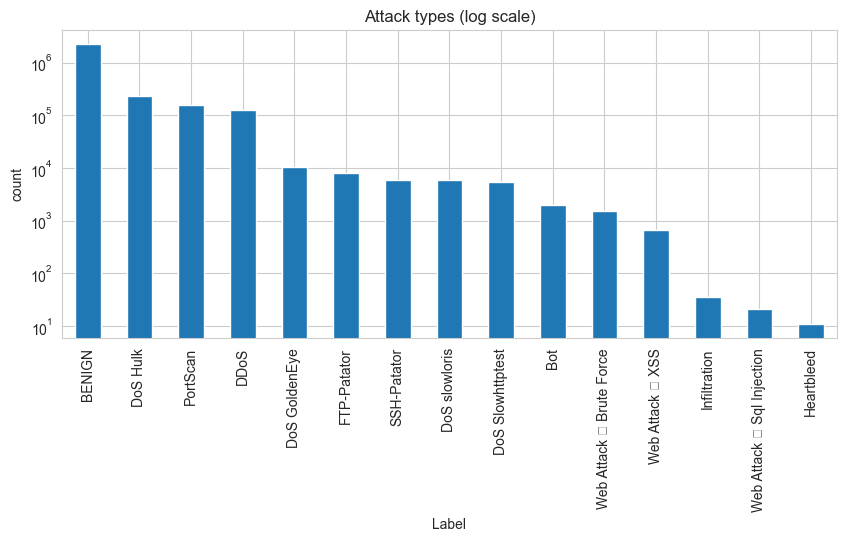

In [4]:
print(df["Label"].value_counts())

df["is_attack"]=(df["Label"] !="BENIGN").astype(int)
print(df["is_attack"].value_counts(normalize=True)*100)

df["Label"].value_counts().plot(kind="bar",logy=True,figsize=(10,4))
plt.title("Attack types (log scale)")
plt.ylabel("count")
plt.show()

In [6]:
# inf ممكن يظهر في Flow Bytes/s و Flow Packets/s
num_cols = df.select_dtypes("number").columns
print("inf count:", np.isinf(df[num_cols]).sum().sum())

df.replace([np.inf, -np.inf], np.nan, inplace=True)
na = df.isna().sum()
print(na[na > 0])

print("duplicates:", df.duplicated().sum(),
      f"({df.duplicated().mean()*100:.1f}%)")

const_cols = [c for c in num_cols if df[c].nunique() <= 1]
print("constant columns:", const_cols)

inf count: 4376
Flow ID             288602
Source IP           288602
Source Port         288602
Destination IP      288602
Destination Port    288602
                     ...  
Idle Mean           288602
Idle Std            288602
Idle Max            288602
Idle Min            288602
Label               288602
Length: 85, dtype: int64
duplicates: 288804 (9.3%)
constant columns: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [7]:
n0 = len(df)

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

const_cols = [c for c in df.select_dtypes("number").columns
              if df[c].nunique() <= 1]
df.drop(columns=const_cols, inplace=True)

print(f"rows: {n0} -> {len(df)}  (removed {n0-len(df)})")

rows: 3119345 -> 2827677  (removed 291668)


In [8]:
import sys
sys.path.append("..")          # lets the notebook import our `src` package
from src.data_loader import parse_timestamps, normalize_labels

print(df["Timestamp"].head())

# FIX: day-first dates, mixed "H:MM" / "H:MM:SS" formats, and 12-hour times without AM/PM
df["Timestamp"] = parse_timestamps(df["Timestamp"])
print("bad timestamps:", df["Timestamp"].isna().sum())   # was 529,450 before the fix

df = df.dropna(subset=["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

# tidy labels ("Web Attack \x96 Brute Force") and add helper columns used later
df["Label"] = normalize_labels(df["Label"])
df["is_attack"] = (df["Label"] != "BENIGN").astype(int)
df["day"] = df["Timestamp"].dt.day_name()

# sanity check: exactly 5 days (3-7 July 2017), working hours only
print(df.groupby("day")["Timestamp"].agg(["min", "max", "count"]))

0    7/7/2017 3:30
1    7/7/2017 3:30
2    7/7/2017 3:30
3    7/7/2017 3:30
4    7/7/2017 3:30
Name: Timestamp, dtype: object
bad timestamps: 0
                          min                 max   count
day                                                      
Friday    2017-07-07 08:59:00 2017-07-07 17:02:00  702713
Monday    2017-07-03 08:55:58 2017-07-03 17:01:34  529450
Thursday  2017-07-06 08:59:00 2017-07-06 17:04:00  458483
Tuesday   2017-07-04 08:53:00 2017-07-04 17:00:00  445641
Wednesday 2017-07-05 08:42:00 2017-07-05 17:10:00  691390


In [9]:
df.to_parquet("../data/processed/clean.parquet", index=False)

## EDA

**Goal:** understand the traffic before modeling. The questions we answer below:

1. How are the main flow features distributed? (skewed? need a transform?)
2. Do attack types behave differently from benign traffic?
3. When do the attacks happen?
4. Which source IPs generate the traffic and the attacks?
5. Which features are redundant, and which ones relate most to the target?
6. Which features do we keep for modeling?

### 1. Feature distributions
**Question:** are the key flow features skewed, and do they need a transform?

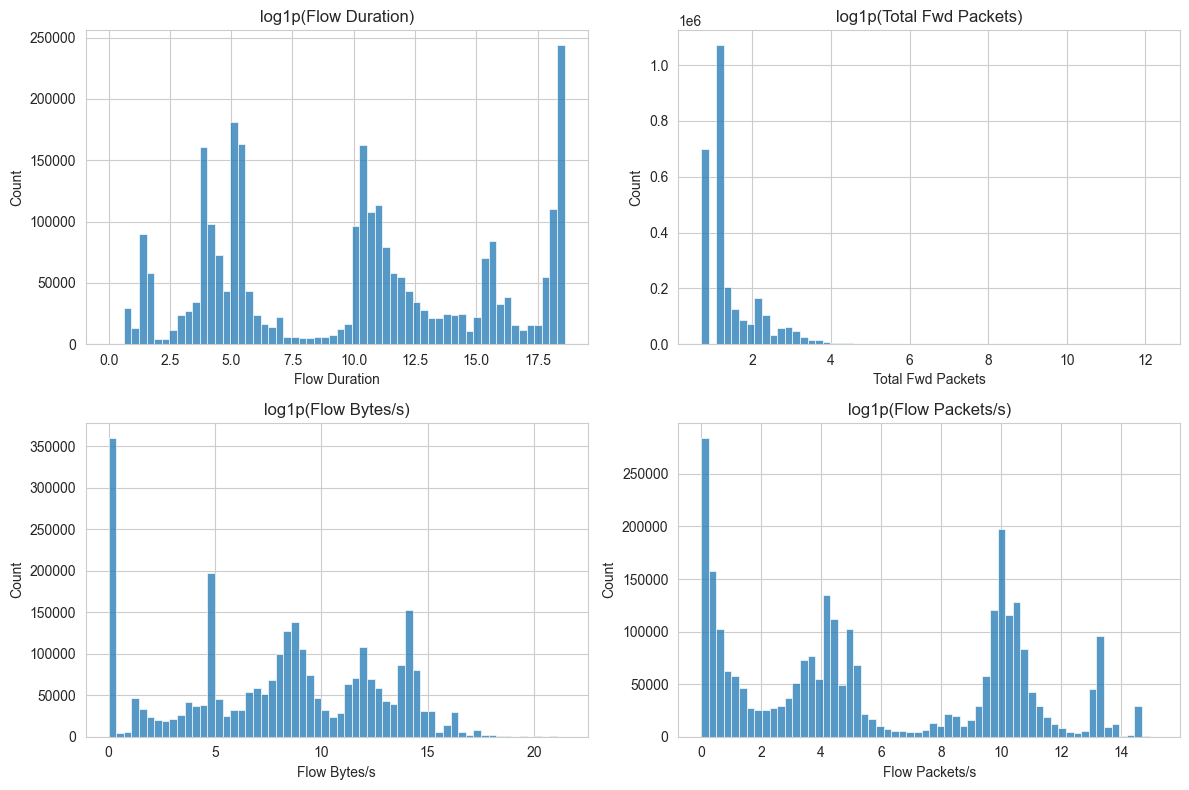

Flow Duration          2.153528
Total Fwd Packets    244.248181
Flow Bytes/s          46.390599
Flow Packets/s         5.519945
dtype: float64


In [10]:
# نعمل log1p عشان القيم skewed جدًا (clip(lower=0) عشان نتجنب القيم السالبة)
key_feats = ["Flow Duration", "Total Fwd Packets", "Flow Bytes/s", "Flow Packets/s"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), key_feats):
    sns.histplot(np.log1p(df[col].clip(lower=0)), bins=60, ax=ax)
    ax.set_title(f"log1p({col})")
plt.tight_layout()
plt.show()

print(df[key_feats].skew())

**Observation:** all four features are right-skewed (skew: Flow Duration ≈ 2.0, Total Fwd Packets ≈ 248, Flow Bytes/s ≈ 45, Flow Packets/s ≈ 5.5), so `log1p` is used to make the shape readable. Scale-sensitive models will need a log or robust transform.

### 2. Benign vs attack behaviour
**Question:** do the attack types differ from benign traffic in duration, packet count and rate?

,Flow Duration,Total Fwd Packets,Flow Bytes/s,Flow Packets/s
Label,,,,
BENIGN,1.123058e+07,10.66,1779747.07,64696.78
Bot,3.527369e+05,3.21,307099.15,46841.28
DDoS,1.695586e+07,4.47,61117.88,172.79
DoS GoldenEye,2.312722e+07,5.90,688.24,9.14
DoS Hulk,5.731738e+07,5.29,29401.84,182509.81
DoS Slowhttptest,5.771989e+07,5.74,21642420.63,22235.78
DoS slowloris,5.655437e+07,6.34,43921.22,4231.88
FTP-Patator,4.514951e+06,5.50,799464.59,115888.89
Heartbleed,1.106797e+08,2583.73,65902.80,40.56


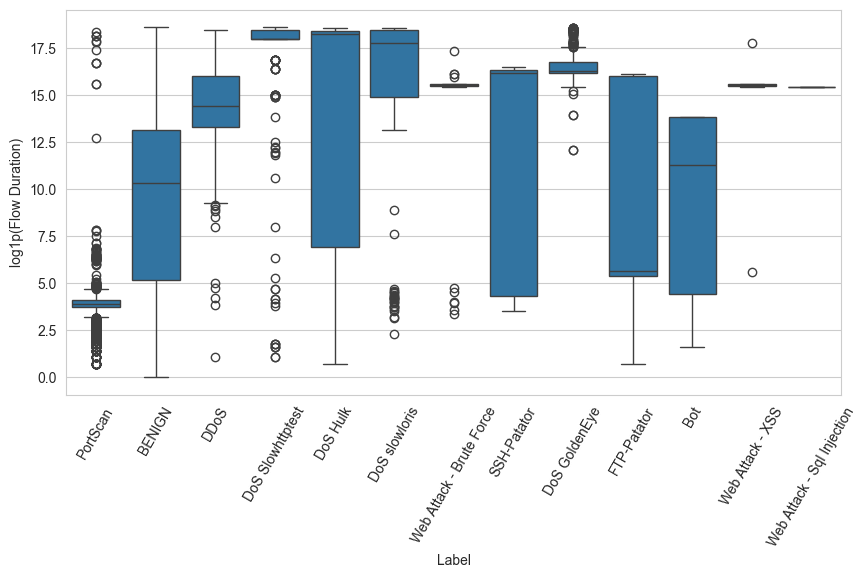

In [11]:
# متوسط كل feature لكل نوع هجوم (Label)
compare = df.groupby("Label")[key_feats].mean()
display(compare.round(2))

# boxplot لعينة
sample = df.sample(100_000, random_state=42)
plt.figure(figsize=(10, 5))
sns.boxplot(data=sample, x="Label", y=np.log1p(sample["Flow Duration"].clip(lower=0)))
plt.xticks(rotation=60)
plt.ylabel("log1p(Flow Duration)")
plt.show()

**Observation:**
- `PortScan` flows are extremely short (mean ≈ 8×10⁴ µs) with ≈ 1 forward packet, unlike benign flows (≈ 1.1×10⁷ µs).
- The DoS variants (Hulk, slowloris, Slowhttptest, GoldenEye) have much longer mean durations than benign.
- `Heartbleed` and `Infiltration` show very large forward packet counts, but they have only 11 and 36 samples, so those means are unreliable.
- Means are pulled by outliers, which is why the boxplot uses a log scale.

### 3. Traffic over time
**Question:** when do attacks happen compared to normal traffic?

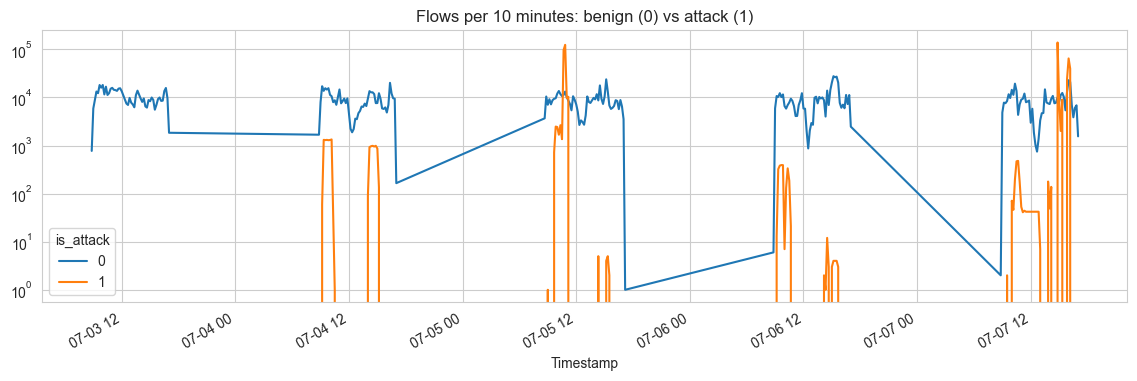

In [13]:
# عدد الـ flows كل 10 دقايق: benign (0) مقابل attack (1) - log scale عشان الفرق كبير
ts = (df.set_index("Timestamp")
        .groupby([pd.Grouper(freq="10min"), "is_attack"])
        .size().unstack(fill_value=0))

ts.plot(figsize=(14, 4), logy=True)
plt.title("Flows per 10 minutes: benign (0) vs attack (1)")
plt.show()

**Observation:** benign traffic is continuous, while attacks appear as short bursts of up to ~10⁵ flows per 10 minutes.

> ✅ **Dates fixed:** the timestamps are day-first, some rows have seconds and some do not, and the clock is 12-hour without AM/PM. `parse_timestamps` in `src/data_loader.py` handles all three, so no rows are lost and the plot covers 3-7 July 2017. Re-check the numbers in this section after re-running.

### 4. Source IP analysis
**Question:** is the traffic spread evenly across IPs, or dominated by a few?

In [14]:
# توزيع الـ flows على الـ Source IP وأكتر IPs مسؤولة عن هجمات
src = df["Source IP"].value_counts()
print(src.describe())
print(src.head(10))

print("share of flows from top 10 IPs:",
      round(src.head(10).sum() / len(df) * 100, 1), "%")

# أكتر IPs عندها هجمات
print(df[df.is_attack == 1]["Source IP"].value_counts().head(5))

count     17002.000000
mean        166.314375
std        6094.199771
min           1.000000
25%           2.000000
50%           5.000000
75%          14.000000
max      558159.000000
Name: count, dtype: float64
Source IP
172.16.0.1       558159
192.168.10.3     298944
192.168.10.8     214909
192.168.10.5     170041
192.168.10.9     152511
192.168.10.12    146178
192.168.10.15    145971
192.168.10.14    140926
192.168.10.17    123138
192.168.10.16    122002
Name: count, dtype: int64
share of flows from top 10 IPs: 73.3 %
Source IP
172.16.0.1        554560
205.174.165.73       701
192.168.10.15        366
192.168.10.8         307
192.168.10.9         226
Name: count, dtype: int64


**Observation:**
- There are ~15k unique source IPs, but the top 10 produce 76.4% of all flows (median is only 4 flows per IP).
- `172.16.0.1` alone sends 558,158 flows, and 554,560 of them are attacks, so almost all attack traffic comes from this one address.
- Because of this, `Source IP` (and `Flow ID`, which contains it) would leak the label, so it should not be used as a model feature.

### 5. Correlation analysis
**Question:** which features carry the same information, and which relate most to the target?

#### 5.1 Correlation matrix

In [15]:
# feature columns = كل الأعمدة الرقمية ما عدا الـ target
feat_cols = [c for c in df.select_dtypes("number").columns if c != "is_attack"]

# correlation matrix على الـ sample (أسرع من الداتا كلها)
corr = sample[feat_cols].corr()
print(len(feat_cols), "numeric features")

72 numeric features


#### 5.2 Highly correlated (redundant) feature pairs

In [16]:
# ناخد المثلث العلوي بس من corr عشان كل pair تظهر مرة واحدة، ونطلع الأزواج اللي |corr| > 0.9
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_pairs = upper.stack().loc[lambda s: s.abs() > 0.9].sort_values(ascending=False)
print(len(high_pairs), "pairs above 0.9")
print(high_pairs.head(15))

78 pairs above 0.9
Total Fwd Packets            Subflow Fwd Packets     1.000000
Total Length of Fwd Packets  Subflow Fwd Bytes       1.000000
Total Backward Packets       Subflow Bwd Packets     1.000000
Fwd Header Length            Fwd Header Length.1     1.000000
Bwd Packet Length Mean       Avg Bwd Segment Size    1.000000
Fwd Packet Length Mean       Avg Fwd Segment Size    1.000000
Fwd URG Flags                CWE Flag Count          1.000000
RST Flag Count               ECE Flag Count          1.000000
Fwd PSH Flags                SYN Flag Count          1.000000
Fwd Header Length            min_seg_size_forward    1.000000
Fwd Header Length.1          min_seg_size_forward    1.000000
Total Length of Bwd Packets  Subflow Bwd Bytes       1.000000
Flow Duration                Fwd IAT Total           0.998466
Flow IAT Max                 Fwd IAT Max             0.997923
Packet Length Mean           Average Packet Size     0.997783
dtype: float64


**Observation:** 83 pairs have |corr| > 0.9, and several are exact duplicates (correlation = 1.0), for example `Total Fwd Packets` and `Subflow Fwd Packets`, or `Fwd Packet Length Mean` and `Avg Fwd Segment Size`. These add no information.

#### 5.3 Correlation with the target

Bwd Packet Length Std     0.509929
Bwd Packet Length Max     0.492288
Avg Bwd Segment Size      0.484395
Bwd Packet Length Mean    0.484395
Packet Length Std         0.469744
Max Packet Length         0.453359
Packet Length Variance    0.452675
Fwd IAT Std               0.418675
Packet Length Mean        0.415007
Average Packet Size       0.414124
Idle Max                  0.390461
Idle Mean                 0.386222
Fwd IAT Max               0.384576
Flow IAT Max              0.384457
Idle Min                  0.375383
dtype: float64


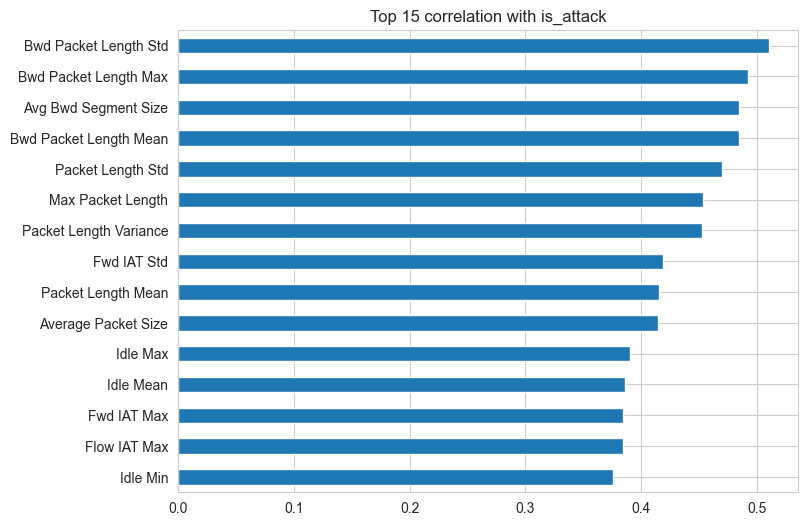

In [ ]:
# علاقة كل feature بالـ target (is_attack) - على الـ sample
target_corr = (sample[feat_cols].corrwith(sample["is_attack"])
                 .dropna()
                 .sort_values(key=abs, ascending=False))
print(target_corr.head(15))
target_corr.head(15).plot(kind="barh", figsize=(8, 6))
plt.gca().invert_yaxis()
plt.title("Top 15 correlation with is_attack")
plt.show()

**Observation:** the strongest single correlation with `is_attack` is only ≈ 0.50 (`Bwd Packet Length Std`), followed by packet-length and inter-arrival-time (IAT) features. No single feature separates attacks from benign traffic, so a multi-feature model is needed.

### 6. Feature selection
**Question:** which features do we keep for modeling?

In [17]:
# لو feature مرتبطة بـ feature تانية بأكتر من 0.95 نشيلها (redundant)
to_drop = [c for c in upper.columns if (upper[c].abs() > 0.95).any()]
print(len(to_drop), "features to drop")

final_features = [c for c in feat_cols if c not in to_drop]
print(len(final_features), "features kept")

25 features to drop
47 features kept


### EDA summary
- **Skewed features:** use a log transform (or a robust scaler).
- **Class imbalance:** the attack classes are very unbalanced (see the label counts above); the rarest ones (Heartbleed, Infiltration, Web Attack SQL Injection) have very few samples, so use stratified splits and imbalance-aware metrics.
- **Leakage:** do not use `Source IP` or `Flow ID`.
- **Redundancy:** 26 highly correlated features dropped, 46 kept.
- **Time:** timestamp parsing is fixed; we split by capture day (Mon = train, Tue = validation, Wed-Fri = test).

## 7. Preprocessing for sequence models

Decisions made from the EDA above:

| Decision | Reason |
|---|---|
| Drop `Flow ID`, `Source IP`, `Destination IP`, `Source Port`, `Timestamp` | identifiers: `172.16.0.1` alone is the attacker, so they leak the label |
| Signed `log1p` on every feature | features are extremely right-skewed; some legitimately negative |
| Drop features with \|corr\| > 0.95 | exact duplicates add no information |
| z-score fitted on **Monday benign only**, clipped to ±10 | no test information in the scaler; clipping stops one huge outlier dominating the loss |
| Windows of 10 consecutive flows, sorted by timestamp, never crossing a day | turns flow rows into time-series samples |
| Window is "attack" if it contains at least one attack flow | an alert is useful even if only part of the window is malicious |

In [18]:
from src.config import *
from src.pipeline import fit_preprocessor, build_splits, save_splits

# which attack families fall on which day -> this drives the split design
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
pd.crosstab(df["Label"], df["day"]).reindex(columns=days)

day,Monday,Tuesday,Wednesday,Thursday,Friday
Label,,,,,
BENIGN,529450,431809,439668,456267,413928
Bot,0,0,0,0,1956
DDoS,0,0,0,0,128025
DoS GoldenEye,0,0,10293,0,0
DoS Hulk,0,0,230123,0,0
DoS Slowhttptest,0,0,5499,0,0
DoS slowloris,0,0,5796,0,0
FTP-Patator,0,7935,0,0,0
Heartbleed,0,0,11,0,0


### Split by day (no temporal leakage)
* **Train - Monday:** benign traffic only (the autoencoder never sees an attack).
* **Validation - Tuesday + Wednesday:** FTP/SSH-Patator (brute force) and the DoS family. Used only to choose hyper-parameters and the alert threshold. Tuesday alone was too weak: Patator flows look almost like normal logins, so a threshold tuned on it flagged half of all normal traffic.
* **Test - Thursday + Friday:** web attacks, infiltration, botnet, port scan and DDoS. None of these families appear in training or validation.

In [19]:
pre = fit_preprocessor(df)           # fitted on benign Monday flows only
print(len(pre.features_), "features kept,", len(pre.dropped_corr_), "dropped as redundant")
print(pre.features_)

37 features kept, 32 dropped as redundant
['Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Min', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow IAT Std', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Std', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Std', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Header Length', 'Bwd Packets/s', 'FIN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Active Std']


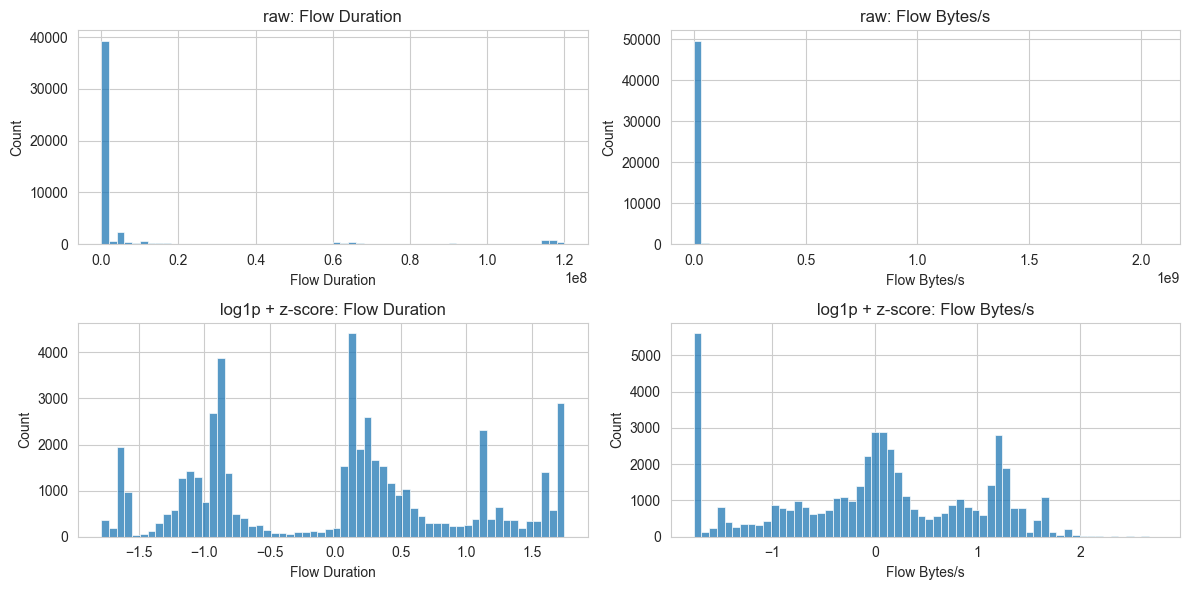

In [20]:
# effect of the transform on two skewed features
feat = [f for f in ["Flow Duration", "Flow Bytes/s"] if f in pre.features_]
mon = df[df.day == "Monday"]
mon = mon.sample(min(50_000, len(mon)), random_state=42)
Z = pd.DataFrame(pre.transform(mon), columns=pre.features_)
fig, axes = plt.subplots(2, len(feat), figsize=(6 * len(feat), 6), squeeze=False)
for j, f in enumerate(feat):
    sns.histplot(mon[f].clip(lower=0), bins=60, ax=axes[0, j]).set_title(f"raw: {f}")
    sns.histplot(Z[f], bins=60, ax=axes[1, j]).set_title(f"log1p + z-score: {f}")
plt.tight_layout(); plt.show()

In [21]:
splits = build_splits(df, pre)
print("window tensor:", splits["X_train"].shape, "= (windows, flows per window, features)")
summary = pd.DataFrame({
    s: {"windows": len(splits[f"X_{s}"]),
        "attack windows": int(splits[f"y_{s}"].sum()),
        "attack %": round(100 * splits[f"y_{s}"].mean(), 1)}
    for s in ["train", "val", "test"]}).T
summary

window tensor: (105889, 10, 37) = (windows, flows per window, features)


,windows,attack windows,attack %
train,105889.0,0.0,0.0
val,113703.0,34292.0,30.2
test,116119.0,32295.0,27.8


,val,test
BENIGN,79411,83824
Bot,0,1200
DDoS,0,12948
DoS GoldenEye,1544,0
DoS Hulk,24346,0
DoS Slowhttptest,1042,0
DoS slowloris,1554,0
FTP-Patator,2891,0
Heartbleed,11,0
Infiltration,0,36


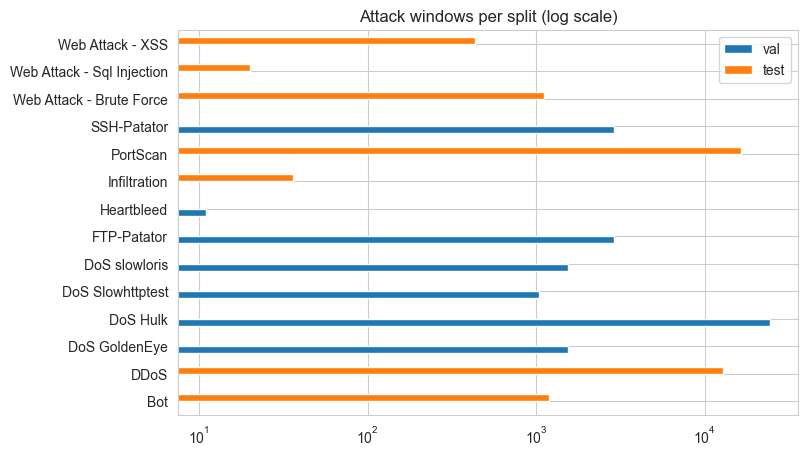

In [22]:
classes = splits["classes"]
cnt = pd.DataFrame({s: pd.Series(splits[f"t_{s}"]).map(dict(enumerate(classes))).value_counts()
                    for s in ["val", "test"]}).fillna(0).astype(int)
display(cnt)
cnt.drop(index="BENIGN").plot(kind="barh", logx=True, figsize=(8, 5),
                              title="Attack windows per split (log scale)")
plt.show()

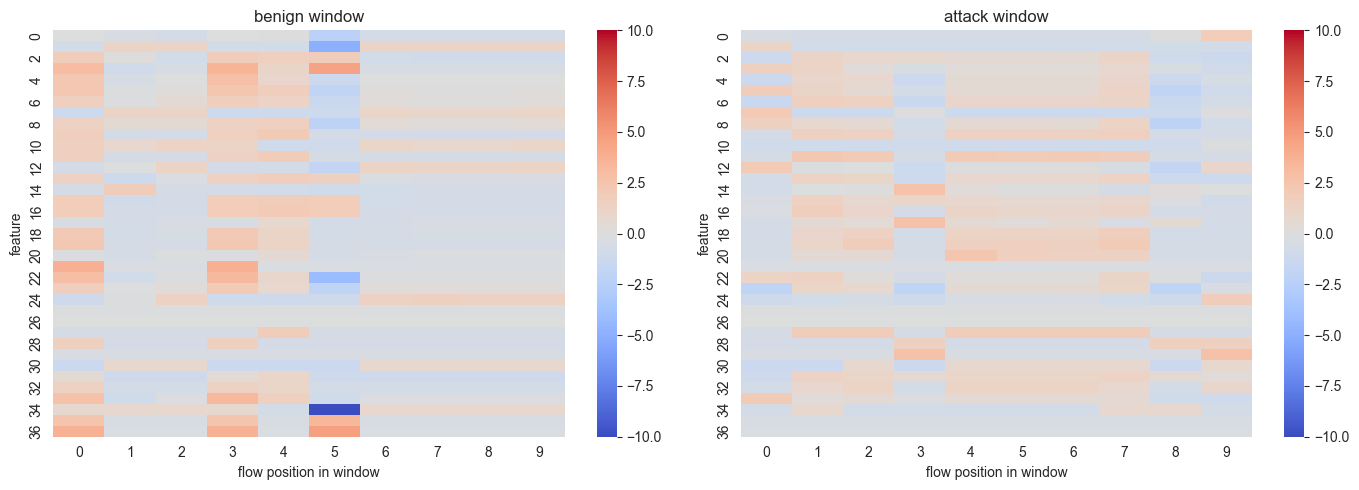

In [23]:
# what the model actually sees: one benign window vs one attack window (features x 10 flows)
ben = splits["X_test"][splits["y_test"] == 0][0]
att = splits["X_test"][splits["y_test"] == 1][0]
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for a, w, t in zip(ax, [ben, att], ["benign window", "attack window"]):
    sns.heatmap(w.T, ax=a, cmap="coolwarm", center=0, vmin=-10, vmax=10)
    a.set_title(t); a.set_xlabel("flow position in window"); a.set_ylabel("feature")
plt.tight_layout(); plt.show()

### Class imbalance strategy
We do **not** resample (no SMOTE): the autoencoder is trained on benign windows only, so imbalance does not affect training. Imbalance is handled at **evaluation** time with PR-AUC, precision, recall, F1 and the false-positive rate instead of accuracy.

In [24]:
pre.save(MODEL_DIR / "preprocessor.joblib")
save_splits(splits)
print("saved preprocessor and data/processed/sequences.npz -> continue in 02_modeling.ipynb")

saved preprocessor and data/processed/sequences.npz -> continue in 02_modeling.ipynb
